## ProCast results 

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

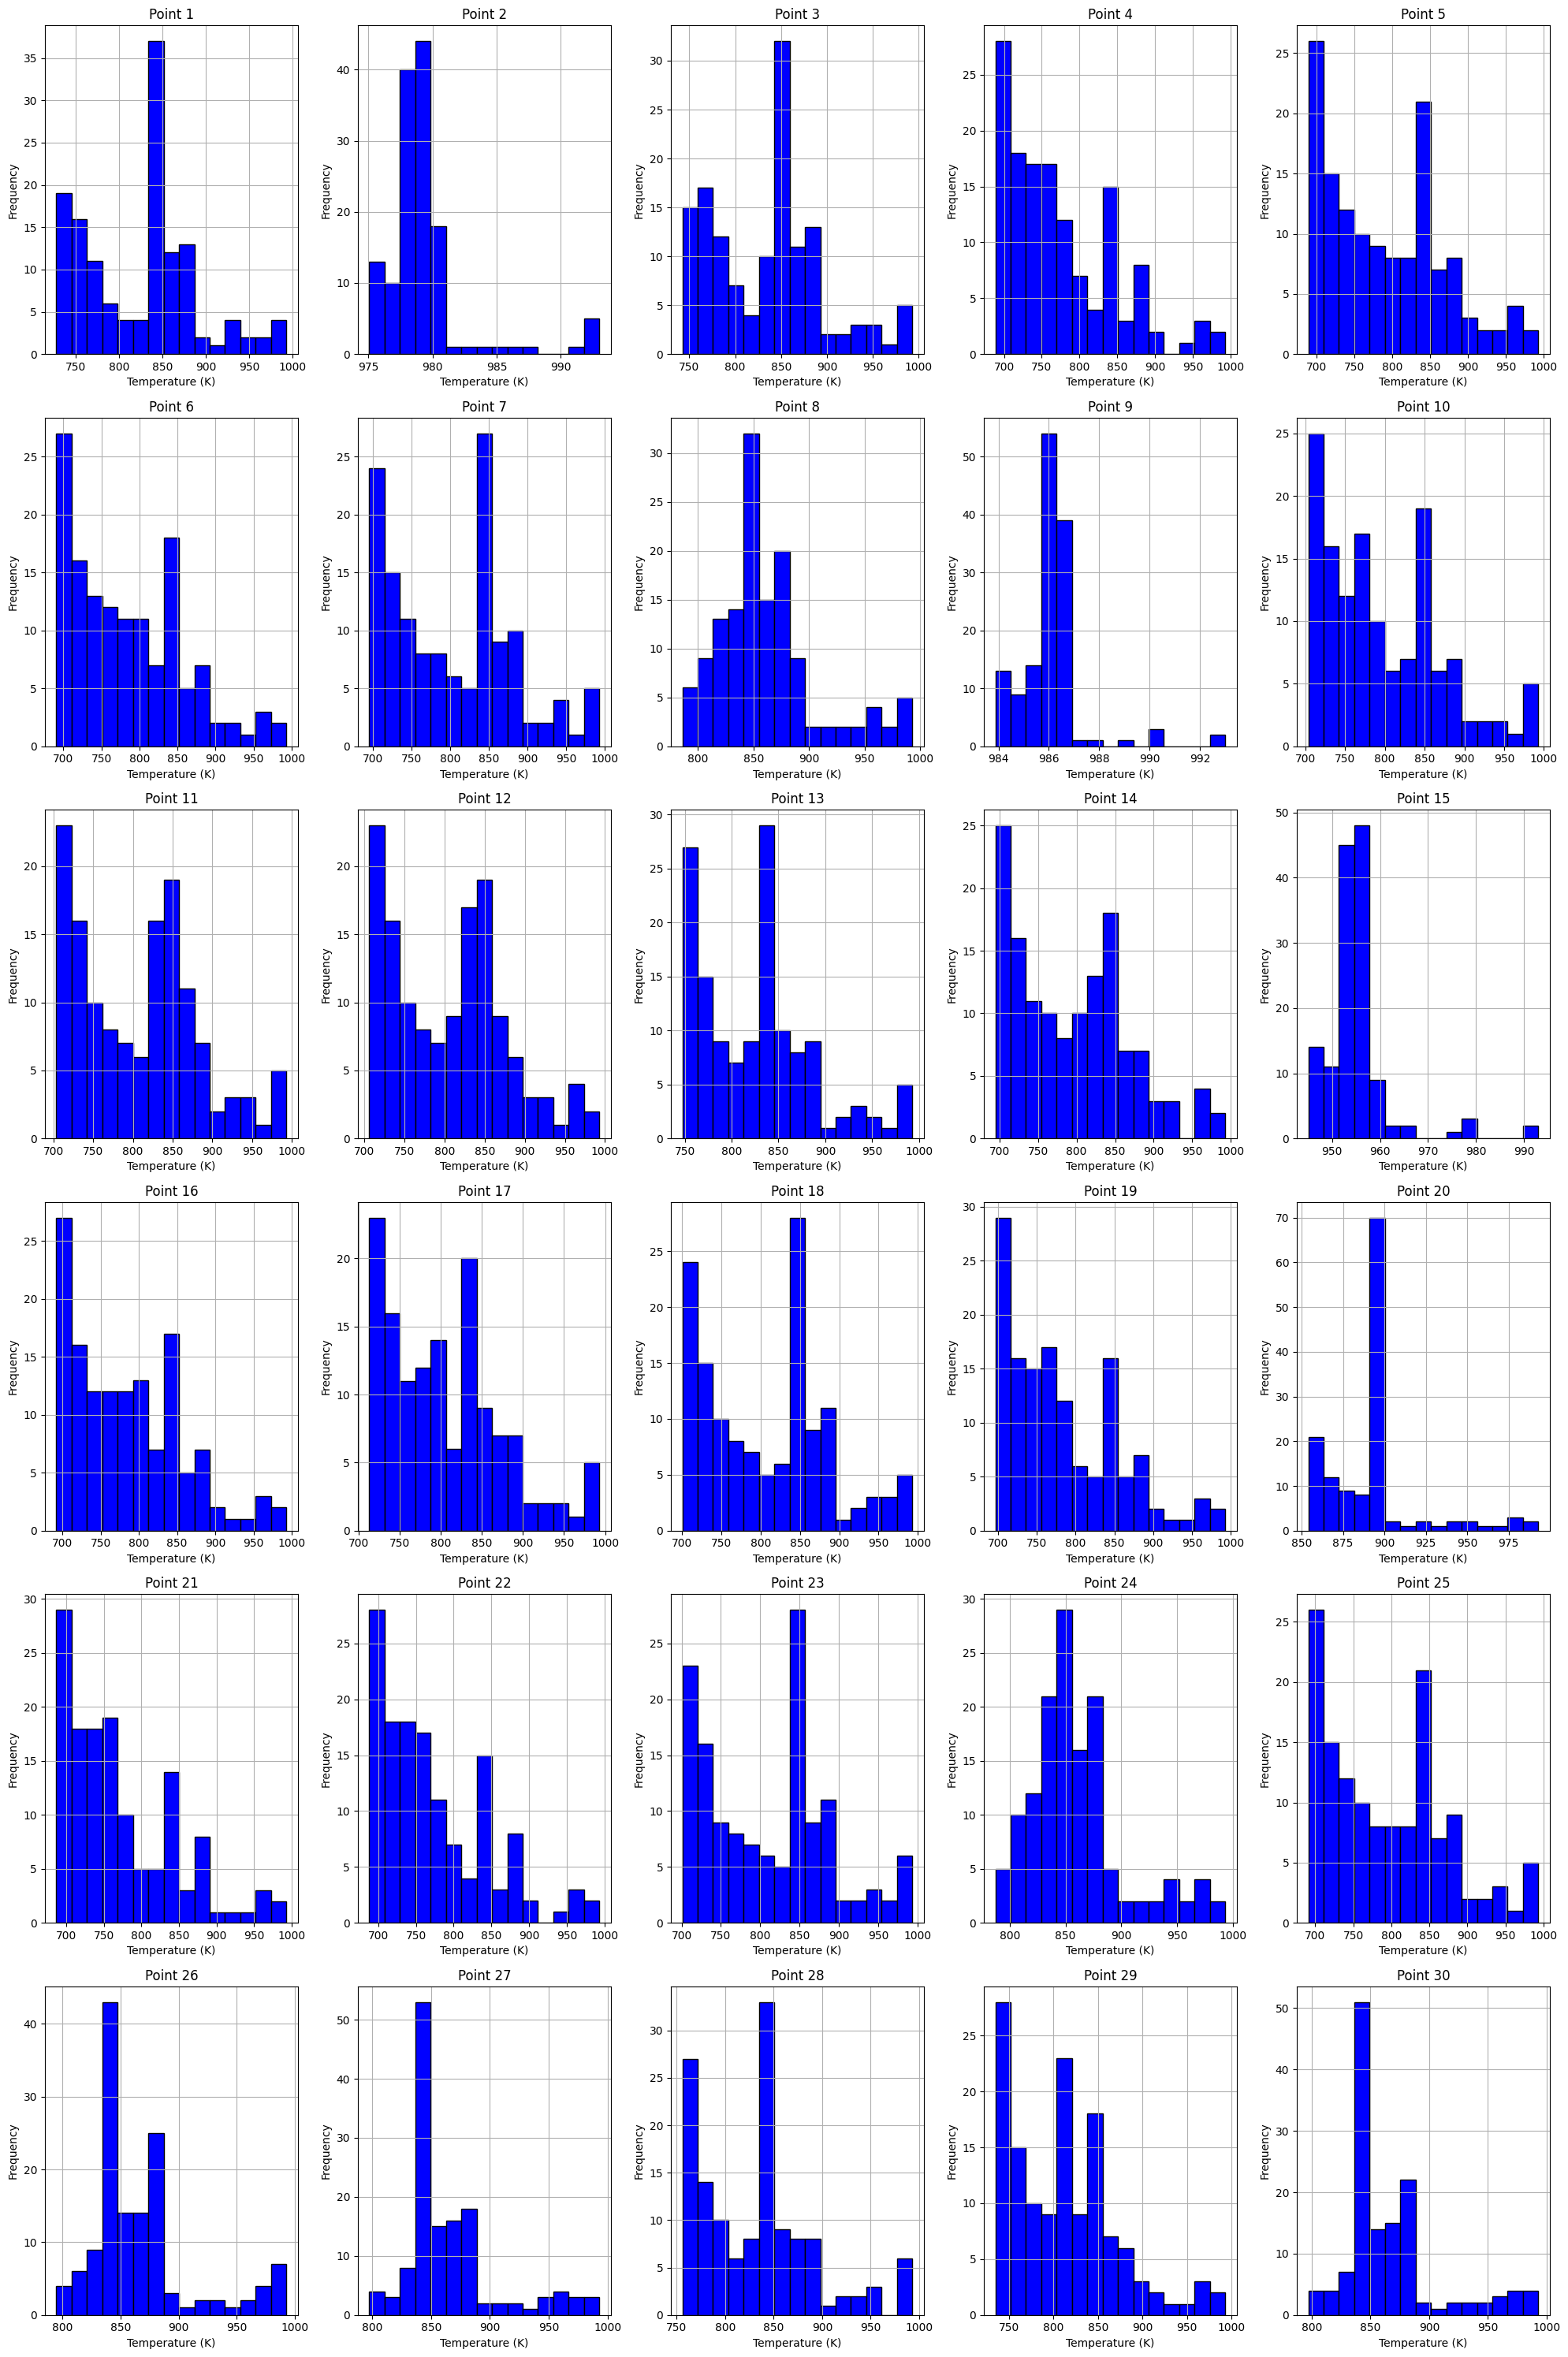

In [ ]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Step 1: Load all CSV files from the folder
folder_path = 'teste'  # Replace with your folder path
all_files = [os.path.join(folder_path, f) for f in os.listdir(folder_path) if f.endswith('.csv')]

# Step 2: Choose random points from the first state (CSV file)
first_state_df = pd.read_csv(all_files[0])
random_points = first_state_df.sample(n=30, random_state=42)  # Randomly select 30 points
random_coordinates = random_points[['X', 'Y', 'Z']]  # Extract coordinates of the random points

# Step 3: For each state, extract temperatures for the chosen points
point_temperature_data = []

for file in all_files:
    state_df = pd.read_csv(file)
    # Merge the state data with the random points based on coordinates
    merged_df = pd.merge(random_coordinates, state_df, on=['X', 'Y', 'Z'], how='left')
    point_temperature_data.append(merged_df['Temperature(K)'])

# Step 4: Create a DataFrame for each point
point_temperature_df = pd.DataFrame(point_temperature_data).T  # Transpose to have points as rows
point_temperature_df.columns = [f'State_{i+1}' for i in range(len(all_files))]  # Rename columns

# Step 5: Plot all 30 histograms in one figure
plt.figure(figsize=(20, 30))  # Adjust the figure size to accommodate all subplots
num_points = len(point_temperature_df)
num_cols = 5  # Number of columns in the subplot grid
num_rows = int(np.ceil(num_points / num_cols))  # Calculate the number of rows needed

for index, row in point_temperature_df.iterrows():
    plt.subplot(num_rows, num_cols, index + 1)  # Create a subplot for each point
    plt.hist(row, bins=15, color='blue', edgecolor='black')
    plt.title(f'Point {index + 1}')
    plt.xlabel('Temperature (K)')
    plt.ylabel('Frequency')
    plt.grid(True)

plt.tight_layout()  # Adjust layout to prevent overlap
plt.show()






['/home/scohail/Desktop/LowCast_AI-Simulation/Data_614C/state000000000001.csv', '/home/scohail/Desktop/LowCast_AI-Simulation/Data_614C/state000000000251.csv', '/home/scohail/Desktop/LowCast_AI-Simulation/Data_614C/state000000000501.csv', '/home/scohail/Desktop/LowCast_AI-Simulation/Data_614C/state000000000751.csv', '/home/scohail/Desktop/LowCast_AI-Simulation/Data_614C/state000000001001.csv', '/home/scohail/Desktop/LowCast_AI-Simulation/Data_614C/state000000001251.csv', '/home/scohail/Desktop/LowCast_AI-Simulation/Data_614C/state000000001501.csv', '/home/scohail/Desktop/LowCast_AI-Simulation/Data_614C/state000000001751.csv', '/home/scohail/Desktop/LowCast_AI-Simulation/Data_614C/state000000002001.csv', '/home/scohail/Desktop/LowCast_AI-Simulation/Data_614C/state000000002251.csv', '/home/scohail/Desktop/LowCast_AI-Simulation/Data_614C/state000000002501.csv', '/home/scohail/Desktop/LowCast_AI-Simulation/Data_614C/state000000002751.csv', '/home/scohail/Desktop/LowCast_AI-Simulation/Data_6

<Figure size 1500x2000 with 0 Axes>

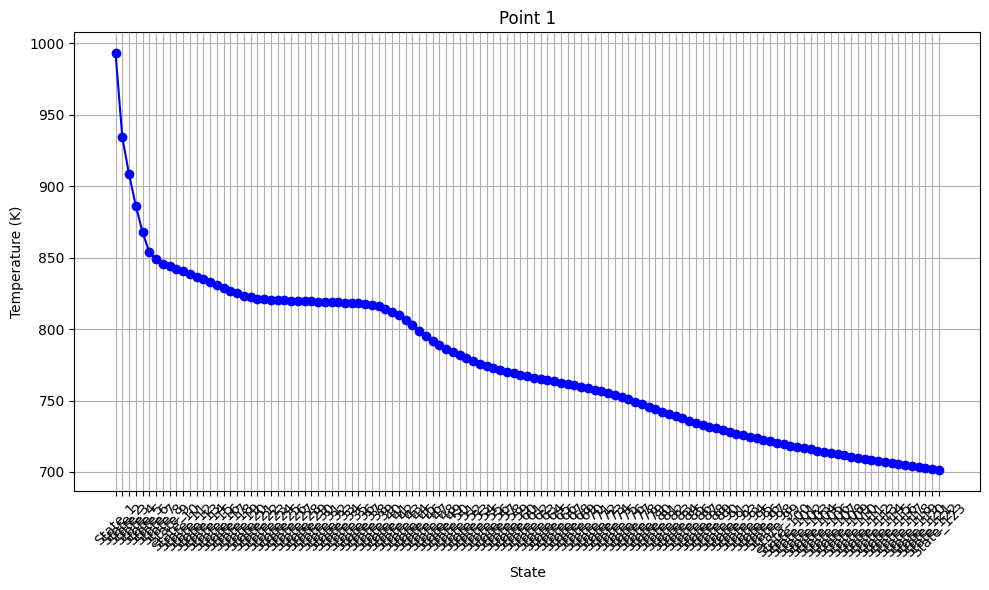

In [ ]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Step 1: Load all CSV files from the folder
folder_path = '/home/scohail/Desktop/LowCast_AI-Simulation/Data_664C'  # Replace with your folder path
all_files = [os.path.join(folder_path, f) for f in os.listdir(folder_path) if f.endswith('.csv')]
all_files.sort(key=lambda x: int(x.split('state')[-1].split('.csv')[0]))


print(all_files)

# Step 2: Choose random points from the first state (CSV file)
# first_state_df = pd.read_csv(all_files[0])
# random_points = first_state_df.sample(n=30, random_state=42)  # Randomly select 30 points


# print(random_points)

#choose a specific point

random_points = pd.DataFrame({'X': [2.2771757], 'Y': [0.92087674], 'Z': [-4.2632566e-15]})



random_coordinates = random_points[['X', 'Y', 'Z']]  # Extract coordinates of the random points

# # Step 3: For each state, extract temperatures for the chosen points
point_temperature_data = []

for file in all_files:
    state_df = pd.read_csv(file)
    # Merge the state data with the random points based on coordinates
    merged_df = pd.merge(random_coordinates, state_df, on=['X', 'Y', 'Z'], how='left')
    point_temperature_data.append(merged_df['Temperature(K)'])

# Step 4: Create a DataFrame for each point
point_temperature_df = pd.DataFrame(point_temperature_data).T  # Transpose to have points as rows
point_temperature_df.columns = [f'State_{i+1}' for i in range(len(all_files))]  # Rename columns

# Step 5: Plot temperature as a function of states for each point
plt.figure(figsize=(15, 20))  # Adjust the figure size to accommodate all subplots
num_points = len(point_temperature_df)
num_cols = 5  # Number of columns in the subplot grid
num_rows = int(np.ceil(num_points / num_cols))  # Calculate the number of rows needed

for index, row in point_temperature_df.iterrows():
    plt.figure(figsize=(10, 6))
    # plt.subplot(num_rows, num_cols, index + 1)  # Create a subplot for each point
    plt.plot(row, marker='o', linestyle='-', color='blue')  # Line plot with markers
    plt.title(f'Point {index + 1}')
    plt.xlabel('State')
    plt.ylabel('Temperature (K)')
    plt.xticks(rotation=45)  # Rotate x-axis labels for better readability
    plt.grid(True)

plt.tight_layout()  # Adjust layout to prevent overlap
plt.show()

## Testing Models

In [2]:
import pandas as pd
import glob
import os


In [3]:

# Path to the folder containing CSV files
folder_path = "teste"

# Get all CSV files in the folder
csv_files = sorted(glob.glob(os.path.join(folder_path, "state*.csv")))

# Initialize an empty DataFrame
final_df = None



In [4]:
for file in csv_files:
    # Extract the state number from the filename
    state_number = os.path.basename(file).replace("state", "").lstrip("0")
    
    # Read CSV file
    df = pd.read_csv(file)

    # Filter rows where Z == -4.2632566e-15
    df_filtered = df[df["Z"] == -4.2632566e-15][["X", "Y", "Temperature(K)"]]

    # Rename temperature column to reflect the state number
    df_filtered.rename(columns={"Temperature(K)": f"TempState{state_number}"}, inplace=True)

    # Merge with the final DataFrame
    if final_df is None:
        final_df = df_filtered
    else:
        final_df = pd.merge(final_df, df_filtered, on=["X", "Y"], how="outer")

# Save the final DataFrame or display it
print(final_df)
# final_df.to_csv("merged_temperatures.csv", index=False)


             X          Y  TempState1.csv  TempState6.csv  TempState11.csv  \
0    -3.323856   6.720222           993.0       991.68866        977.08780   
1    -3.305937   6.905824           993.0       991.92820        974.98310   
2    -3.300470   6.813534           993.0       992.02686        976.39496   
3    -3.299726   6.204810           993.0       991.79960        981.13310   
4    -3.294462   7.078054           993.0       991.36920        972.19710   
...        ...        ...             ...             ...              ...   
4622  5.832240 -15.627687           993.0       992.12250        977.61700   
4623  5.833679 -15.924137           993.0       991.96820        976.04626   
4624  5.846610 -15.526989           993.0       991.96295        977.31660   
4625  5.846827 -15.426255           993.0       991.93640        977.01843   
4626  5.860583 -15.343610           993.0       991.59820        976.32916   

      TempState16.csv  TempState21.csv  TempState26.csv  TempSt

In [5]:
final_df.columns

Index(['X', 'Y', 'TempState1.csv', 'TempState6.csv', 'TempState11.csv',
       'TempState16.csv', 'TempState21.csv', 'TempState26.csv',
       'TempState31.csv', 'TempState36.csv',
       ...
       'TempState636.csv', 'TempState641.csv', 'TempState646.csv',
       'TempState651.csv', 'TempState656.csv', 'TempState661.csv',
       'TempState666.csv', 'TempState671.csv', 'TempState676.csv',
       'TempState681.csv'],
      dtype='object', length=139)

In [9]:
#normalize the data

from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()


final_df_scaled = final_df.copy()

final_df_scaled.iloc[:,:] = scaler.fit_transform(final_df_scaled.iloc[:,:])

print(final_df_scaled)

             X         Y  TempState1.csv  TempState6.csv  TempState11.csv  \
0     0.000000  0.953815             0.0        0.691591         0.850319   
1     0.001951  0.959714             0.0        0.747927         0.830518   
2     0.002546  0.956781             0.0        0.771131         0.843801   
3     0.002627  0.937434             0.0        0.717682         0.888377   
4     0.003200  0.965188             0.0        0.616458         0.804308   
...        ...       ...             ...             ...              ...   
4622  0.996914  0.243522             0.0        0.793624         0.855298   
4623  0.997071  0.234100             0.0        0.757335         0.840520   
4624  0.998479  0.246723             0.0        0.756100         0.852472   
4625  0.998502  0.249924             0.0        0.749856         0.849667   
4626  1.000000  0.252551             0.0        0.670316         0.843182   

      TempState16.csv  TempState21.csv  TempState26.csv  TempState31.csv  \

In [16]:
# split the data into train and test 

from sklearn.model_selection import train_test_split

X = final_df_scaled[['X', 'Y']]
Y = final_df_scaled.drop(['X', 'Y'], axis=1)

X_train, X_test, y_train, y_test = train_test_split(X, Y, test_size=0.2, random_state=42)

print(X_train.shape, X_test.shape, y_train.shape, y_test.shape)



(3701, 2) (926, 2) (3701, 137) (926, 137)


In [24]:
# train a CNN model

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

model = keras.Sequential([
    layers.InputLayer(input_shape=(2,)),
    layers.Dense(128, activation='relu'),
    layers.Dense(500, activation='relu'),
    layers.Dense(300, activation='relu'),
    layers.Dense(200, activation='relu'),
    layers.Dense(137, activation='relu'),
    layers.Dense(137, activation='relu')
])

model.compile(optimizer='adam', loss='mean_squared_error')

model.summary()

history = model.fit(X_train, y_train, epochs=500, batch_size=32, validation_split=0.2)

# plot the training history


/home/scohail/miniconda3/envs/vtk_test/lib/python3.10/site-packages/keras/src/layers/core/input_layer.py:27: UserWarning: Argument `input_shape` is deprecated. Use `shape` instead.
  warnings.warn(


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_12 (Dense)                │ (None, 128)            │           384 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 500)            │        64,500 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ (None, 300)            │       150,300 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_15 (Dense)                │ (None, 200)            │        60,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_16 (Dense)                │ (None, 137)            │        27,537 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_17 (Dense)                │ (None, 137)            │        18,906 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 321,827 (1.23 MB)

 Trainable params: 321,827 (1.23 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/500
93/93 ━━━━━━━━━━━━━━━━━━━━ 6s 27ms/step - loss: 0.3407 - val_loss: 0.2011
Epoch 2/500
93/93 ━━━━━━━━━━━━━━━━━━━━ 2s 22ms/step - loss: 0.1981 - val_loss: 0.1954
Epoch 3/500
93/93 ━━━━━━━━━━━━━━━━━━━━ 2s 22ms/step - loss: 0.1941 - val_loss: 0.1944
Epoch 4/500
93/93 ━━━━━━━━━━━━━━━━━━━━ 2s 23ms/step - loss: 0.1895 - val_loss: 0.1857
Epoch 5/500
93/93 ━━━━━━━━━━━━━━━━━━━━ 2s 23ms/step - loss: 0.1857 - val_loss: 0.1853
Epoch 6/500
93/93 ━━━━━━━━━━━━━━━━━━━━ 2s 25ms/step - loss: 0.1859 - val_loss: 0.1852
Epoch 7/500
93/93 ━━━━━━━━━━━━━━━━━━━━ 2s 23ms/step - loss: 0.1858 - val_loss: 0.1855
Epoch 8/500
93/93 ━━━━━━━━━━━━━━━━━━━━ 2s 23ms/step - loss: 0.1857 - val_loss: 0.1846
Epoch 9/500
93/93 ━━━━━━━━━━━━━━━━━━━━ 2s 20ms/step - loss: 0.1840 - val_loss: 0.1852
Epoch 10/500
93/93 ━━━━━━━━━━━━━━━━━━━━ 2s 21ms/step - loss: 0.1840 - val_loss: 0.1834
Epoch 11/500
93/93 ━━━━━━━━━━━━━━━━━━━━ 2s 21ms/step - loss: 0.1730 - val_loss: 0.1639
Epoch 12/500
93/93 ━━━━━━━━━━━━━━━━━━━━ 2s 25ms/step

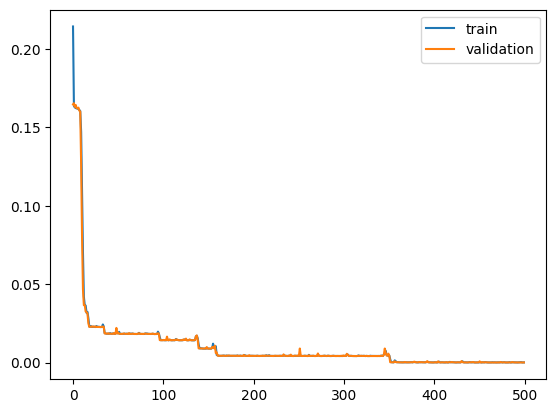

In [41]:
#Plot the training history

plt.plot(history.history['loss'], label='train')
plt.plot(history.history['val_loss'], label='validation')
plt.legend()

plt.show()

In [42]:
# evaluate the model

model.evaluate(X_test, y_test)


29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 4.4868e-05


4.339890801929869e-05

29/29 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step


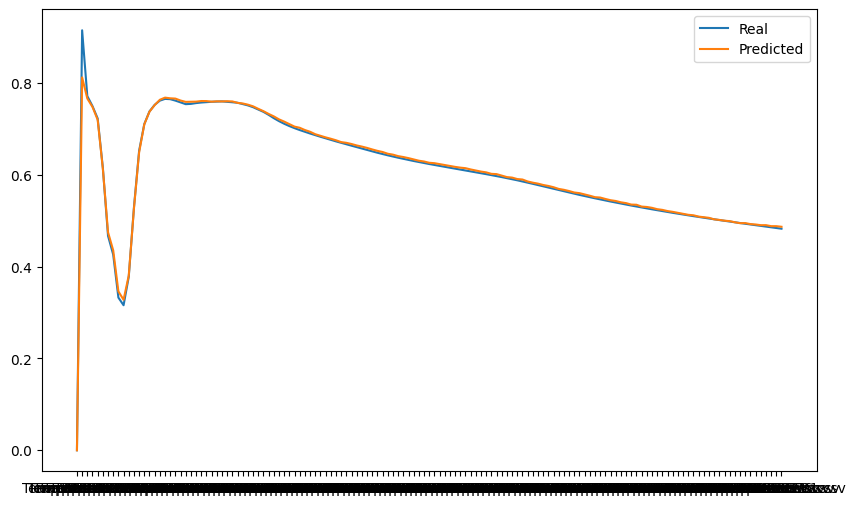

TempState1.csv      0.000000
TempState6.csv      0.819384
TempState11.csv     0.768697
TempState16.csv     0.747983
TempState21.csv     0.720545
                      ...   
TempState661.csv    0.483867
TempState666.csv    0.482642
TempState671.csv    0.481037
TempState676.csv    0.479990
TempState681.csv    0.478575
Name: 10, Length: 137, dtype: float32


In [ ]:
# plot the results of the test data with the real data 

y_pred = model.predict(X_test)

y_pred = pd.DataFrame(y_pred, columns=y_test.columns)

y_test = y_test.reset_index(drop=True)

plt.figure(figsize=(10, 6))

plt.plot(y_test.iloc[1], label='Real')
plt.plot(y_pred.iloc[1], label='Predicted')

plt.legend()

plt.show()

print(y_pred.iloc[10])

In [40]:
# train a CNN model

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

model = keras.Sequential([
    layers.InputLayer(input_shape=(2,)),
    layers.Dense(500, activation='relu'),
    layers.Dense(800, activation='relu'),
    layers.Dense(1000, activation='relu'),
    layers.Dense(300, activation='relu'),
    layers.Dense(200, activation='relu'),
    layers.Dense(137, activation='relu')
])

model.compile(optimizer='adam', loss='mean_squared_error')

model.summary()

history = model.fit(X_train, y_train, epochs=500, batch_size=32, validation_split=0.2)

# plot the training history

/home/scohail/miniconda3/envs/vtk_test/lib/python3.10/site-packages/keras/src/layers/core/input_layer.py:27: UserWarning: Argument `input_shape` is deprecated. Use `shape` instead.
  warnings.warn(


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_18 (Dense)                │ (None, 500)            │         1,500 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_19 (Dense)                │ (None, 800)            │       400,800 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_20 (Dense)                │ (None, 1000)           │       801,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_21 (Dense)                │ (None, 300)            │       300,300 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_22 (Dense)                │ (None, 200)            │        60,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_23 (Dense)                │ (None, 137)            │        27,537 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,591,337 (6.07 MB)

 Trainable params: 1,591,337 (6.07 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/500
93/93 ━━━━━━━━━━━━━━━━━━━━ 9s 44ms/step - loss: 0.2990 - val_loss: 0.1646
Epoch 2/500
93/93 ━━━━━━━━━━━━━━━━━━━━ 4s 37ms/step - loss: 0.1653 - val_loss: 0.1654
Epoch 3/500
93/93 ━━━━━━━━━━━━━━━━━━━━ 4s 46ms/step - loss: 0.1626 - val_loss: 0.1630
Epoch 4/500
93/93 ━━━━━━━━━━━━━━━━━━━━ 4s 39ms/step - loss: 0.1621 - val_loss: 0.1643
Epoch 5/500
93/93 ━━━━━━━━━━━━━━━━━━━━ 4s 38ms/step - loss: 0.1621 - val_loss: 0.1621
Epoch 6/500
93/93 ━━━━━━━━━━━━━━━━━━━━ 4s 47ms/step - loss: 0.1602 - val_loss: 0.1623
Epoch 7/500
93/93 ━━━━━━━━━━━━━━━━━━━━ 5s 48ms/step - loss: 0.1641 - val_loss: 0.1626
Epoch 8/500
93/93 ━━━━━━━━━━━━━━━━━━━━ 3s 35ms/step - loss: 0.1614 - val_loss: 0.1607
Epoch 9/500
93/93 ━━━━━━━━━━━━━━━━━━━━ 4s 45ms/step - loss: 0.1609 - val_loss: 0.1600
Epoch 10/500
93/93 ━━━━━━━━━━━━━━━━━━━━ 4s 42ms/step - loss: 0.1555 - val_loss: 0.1261
Epoch 11/500
93/93 ━━━━━━━━━━━━━━━━━━━━ 3s 36ms/step - loss: 0.1165 - val_loss: 0.0801
Epoch 12/500
93/93 ━━━━━━━━━━━━━━━━━━━━ 3s 34ms/step